<a href="https://colab.research.google.com/github/jhj5445/portfolio/blob/main/sectorport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 비중 재조정 실행 ===

🏆 최종 성과 (2000년~현재): CAGR 11.14% | MDD -39.50% | 누적수수료 17.17%


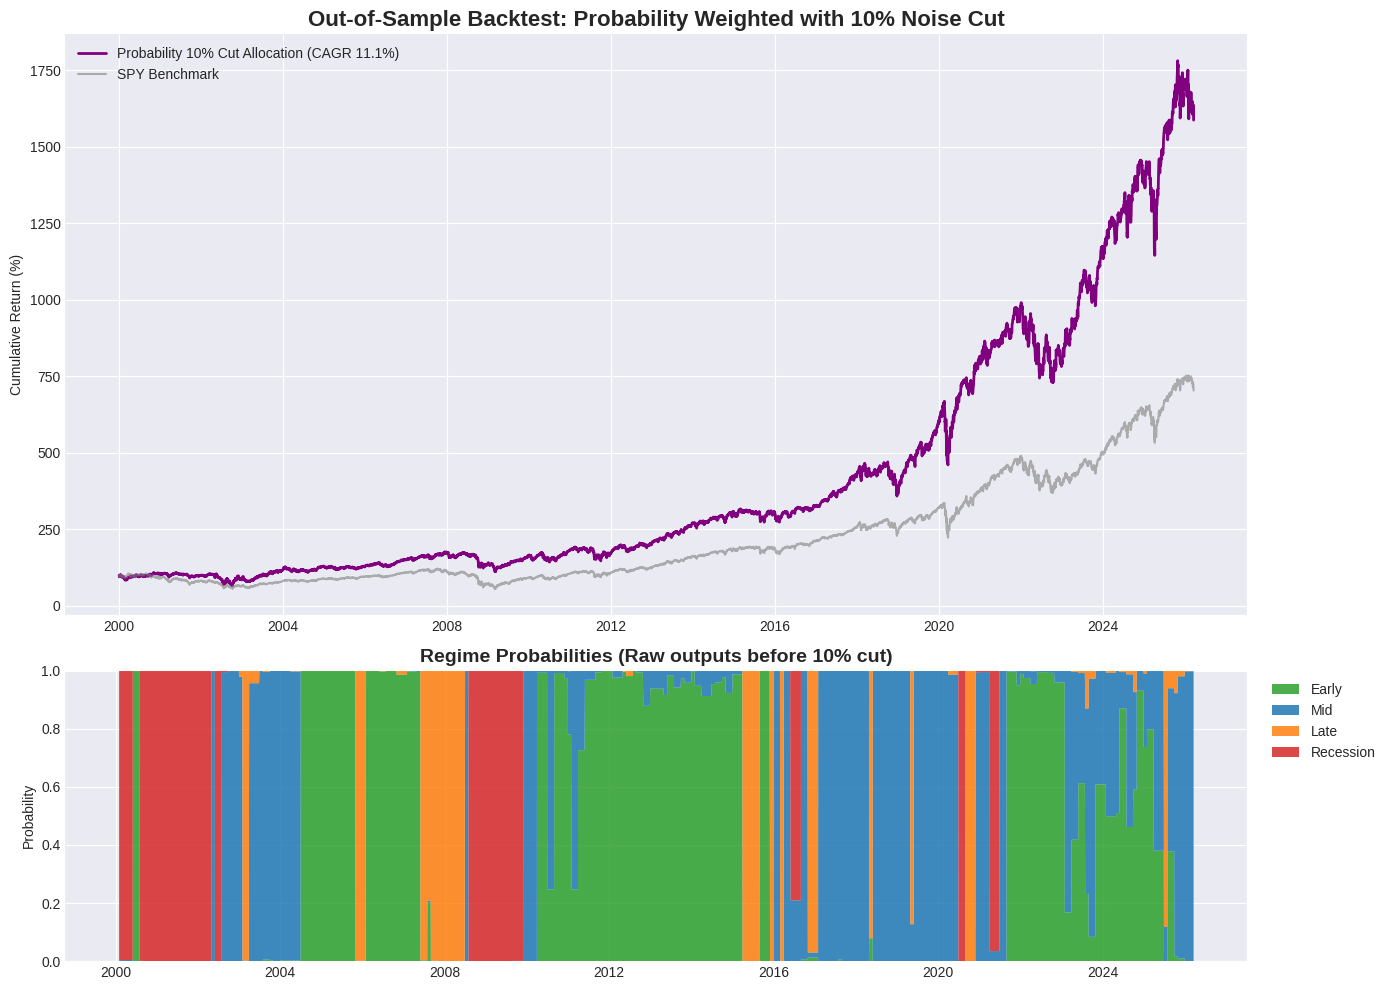

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 전처리 (Expanding Window)
# ==============================================================================
print("=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===")
try:
    s_indpro = fred.get_series('INDPRO')
    s_baa = fred.get_series('BAA10Y')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    df_macro['Growth_Mom'] = (df_macro['Growth'].pct_change(12))
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3)
    df_macro['Emp_Mom'] = (df_macro['Employment'].pct_change(12))
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna()

except Exception as e:
    print(f"🚨 FRED 서버 오류: {e}")
    raise ValueError("FRED 서버 접속 불안정. 잠시 후 다시 실행해주세요.")

# ==============================================================================
# 2. 📈 가격 데이터 로드
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)
test_start_date = '2000-01-01'

etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLV', 'XLU'],
    'Recession': ['XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 백테스트 (💡 10% 노이즈 컷 + 재정규화)
# ==============================================================================
print("=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 비중 재조정 실행 ===")

eom_dates = etf_px.resample('ME').last().index
target_weights = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
dynamic_probs_list = []

for date in eom_dates:
    prob_date = date - pd.DateOffset(months=1)
    df_train_current = df_z.loc[:prob_date]

    if len(df_train_current) > 60:
        gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
        gmm.fit(df_train_current)
        centroids_dynamic = gmm.means_

        # 피델리티 라벨링 로직
        growth_sorted_idx = np.argsort(centroids_dynamic[:, 0])
        idx_recession = growth_sorted_idx[0]
        idx_early = growth_sorted_idx[-1]

        rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
        if centroids_dynamic[rem_idx[0], 1] > centroids_dynamic[rem_idx[1], 1]:
            idx_late, idx_mid = rem_idx[0], rem_idx[1]
        else:
            idx_late, idx_mid = rem_idx[1], rem_idx[0]

        regime_map_dynamic = {
            idx_early: 'Early', idx_mid: 'Mid',
            idx_late: 'Late', idx_recession: 'Recession'
        }

        current_data = df_train_current.iloc[-1:].values
        raw_probs = gmm.predict_proba(current_data)[0]
        current_probs = {regime_map_dynamic[j]: raw_probs[j] for j in range(4)}

        prob_record = current_probs.copy()
        prob_record['Date'] = date
        dynamic_probs_list.append(prob_record)

        # 💡 [핵심 변경] 10% 이상만 남기고 노이즈 제거
        threshold = 0.10
        filtered_probs = {regime: prob for regime, prob in current_probs.items() if prob >= threshold}

        # 혹시라도 모든 확률이 10% 미만인 수학적 기적(오류)이 발생하면, 가장 큰 곳에 100% 몰빵
        if not filtered_probs:
            dominant_regime = max(current_probs, key=current_probs.get)
            filtered_probs = {dominant_regime: 1.0}

        # 남은 확률들의 합을 구해서 다시 100%(1.0)로 스케일업 (정규화)
        # 예: Early 60%, Mid 20% 남았으면 합이 80%. -> Early는 60/80=75%, Mid는 20/80=25%로 재분배
        total_prob = sum(filtered_probs.values())
        normalized_probs = {regime: prob / total_prob for regime, prob in filtered_probs.items()}

        # 정규화된 확률로 섹터 비중 배분
        for regime, prob in normalized_probs.items():
            sectors = cycle_playbook[regime]
            weight_per_sector = prob / len(sectors)
            for s in sectors:
                target_weights.loc[date, s] += weight_per_sector
    else:
        # 데이터 부족 시 SPY 대기
        target_weights.loc[date, 'SPY'] = 1.0

df_dynamic_probs = pd.DataFrame(dynamic_probs_list).set_index('Date')

# 일별 비중 확장 및 수익률 계산
daily_target_weights = target_weights.reindex(daily_returns.index).ffill().shift(1).fillna(0.0)
daily_target_weights.loc[daily_target_weights.sum(axis=1) == 0, 'SPY'] = 1.0

transaction_fee_rate = 0.002
weight_changes = daily_target_weights.diff().fillna(0.0).abs()
daily_costs = weight_changes.sum(axis=1) * transaction_fee_rate

net_daily_return = (daily_target_weights * daily_returns).sum(axis=1) - daily_costs
port_cum_return = (1 + net_daily_return).cumprod()
spy_cum = (1 + daily_returns['SPY']).cumprod()

# ==============================================================================
# 4. 🚀 최종 성과 시각화
# ==============================================================================
total_years = len(port_cum_return) / 252
cagr = (port_cum_return.iloc[-1] ** (1 / total_years)) - 1
mdd = (port_cum_return / port_cum_return.cummax() - 1).min()

print(f"\n🏆 최종 성과 (2000년~현재): CAGR {cagr*100:.2f}% | MDD {mdd*100:.2f}% | 누적수수료 {daily_costs.sum()*100:.2f}%")

plt.style.use('seaborn-v0_8-darkgrid')
fig_backtest, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(port_cum_return.index, port_cum_return * 100, label=f'Probability 10% Cut Allocation (CAGR {cagr*100:.1f}%)', color='purple', linewidth=2)
ax1.plot(spy_cum.index, spy_cum * 100, label='SPY Benchmark', color='gray', alpha=0.6)
ax1.set_title('Out-of-Sample Backtest: Probability Weighted with 10% Noise Cut', fontsize=16, fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(loc='upper left')

probs_aligned = df_dynamic_probs.reindex(port_cum_return.index).ffill().dropna()

ax2.stackplot(probs_aligned.index,
              probs_aligned['Early'], probs_aligned['Mid'],
              probs_aligned['Late'], probs_aligned['Recession'],
              labels=['Early', 'Mid', 'Late', 'Recession'],
              colors=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], alpha=0.85)
ax2.set_title('Regime Probabilities (Raw outputs before 10% cut)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

In [2]:
! pip install fredapi